<a href="https://colab.research.google.com/github/dimmar127-prog/wine-quality-prediction/blob/main/Wine_Quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Data Head ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2 

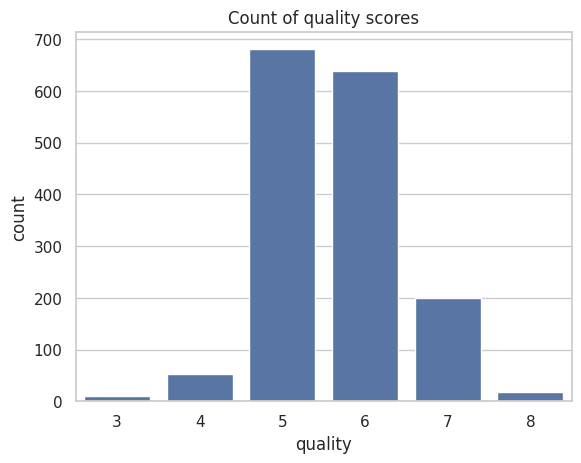

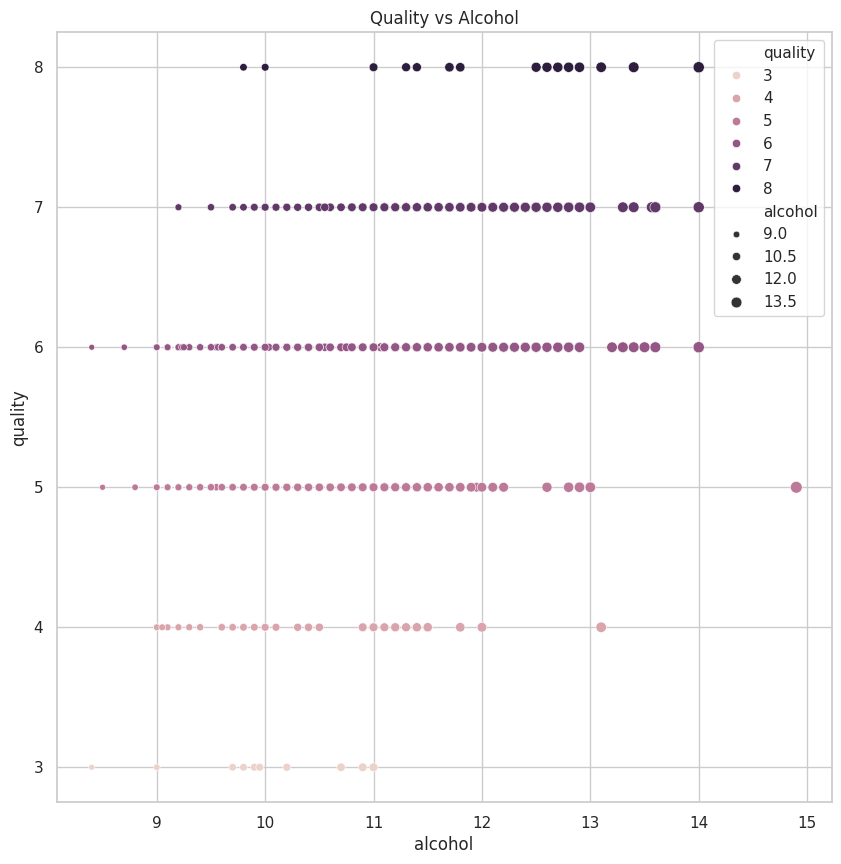

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the data
url = 'https://raw.githubusercontent.com/dimmar127-prog/wine-quality-prediction/refs/heads/main/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print("--- Data Head ---")
print(df.head())
print("\n--- Statistical Summary ---")
print(df.describe())

sns.set_theme(style = 'whitegrid')

# Bar Chart
sns.countplot(x = 'quality', data = df)
plt.title("Count of quality scores")
plt.show()

# Scatter Plot
plt.figure(figsize = (10,10))
# Relationship between 'alcohol' and 'quality'
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', size='alcohol') # size of dots change according to alcohol content
plt.title('Quality vs Alcohol')
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Data Preparation - splitting the input features from the target variable
X = df.drop(columns=['quality'])
y = df['quality']

# Splitting data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Linear Model
model1 = LinearRegression()

# Training the model
model1.fit(X_train, y_train)

# Predictions on the test set
y_pred_lr = model1.predict(X_test)

print('Weights Learned:', model1.coef_)
print('Bias:', model1.intercept_)


Weights Learned: [ 2.30853339e-02 -1.00130443e+00 -1.40821461e-01  6.56431104e-03
 -1.80650315e+00  5.62733439e-03 -3.64444893e-03 -1.03515936e+01
 -3.93687732e-01  8.41171623e-01  2.81889567e-01]
Bias: 14.355105195761777


In [4]:
from sklearn.ensemble import RandomForestRegressor

# Non linear model
model2 = RandomForestRegressor(n_estimators = 100, random_state = 42)
model2.fit(X_train, y_train)
y_pred_rf = model2.predict(X_test)

,Model:,MSE:,R^2:
0,Linear Regression,0.390025,0.403180
1,Random Forest,0.301238,0.539043


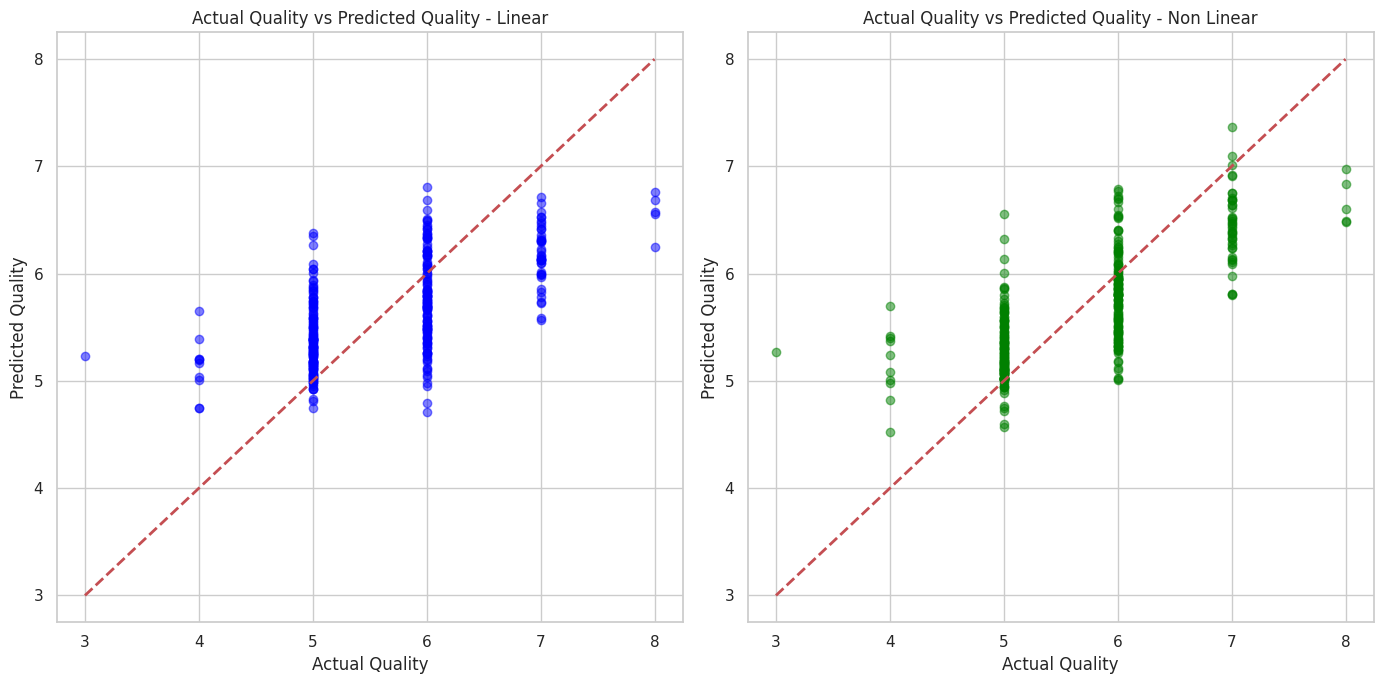

In [5]:
# Calculate metrics
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression metrics
mse_linear = mean_squared_error(y_test, y_pred_lr)
r2_linear = r2_score(y_test, y_pred_lr)

#print('Mean Squared Error: ', mse_linear)
#print('R^2 Score: ', r2_linear)

# Random forest metrics
mse_random = mean_squared_error(y_test, y_pred_rf)
r2_random = r2_score(y_test, y_pred_rf)
#print('Mean Squared Error: ', mse_random)
#print('R^2 Score: ', r2_random)

# Comparison Table
results = {
    'Model:' : ['Linear Regression', 'Random Forest'],
    'MSE:' : [mse_linear, mse_random],
    'R^2:' : [r2_linear, r2_random]
}

comparison_table = pd.DataFrame(results)
display(comparison_table)

#Linear Model plot
plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_lr, alpha = 0.5, color = 'blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # The y=x line
plt.title('Actual Quality vs Predicted Quality - Linear')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')

# Random Forest plot
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_rf, alpha = 0.5, color = 'green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual Quality vs Predicted Quality - Non Linear')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')

plt.tight_layout()
plt.show()





Comparing visually the green dots (Random Forest model) cluster closer to the red line (y=x) than the blue ones .

CONCLUSION

**R2 score comparison:**
The Random Forest model achieved a significantly higher R2 score (0.53) compared to the Linear Regression one (0.4). That 0.13 difference indicates that the non linear model explains about 13% more the variance in wine quality scores than the linear one.

**MSE comparison:**
The Random Forest model also yield a lower MSE (0.3 vs 0.39). That means that it's predictions are closer to the actual quality scores compared to the linear model's predictions.

**Non Linear model's advantage:**
As expected the non linear model managed to predict the wine quality scores better than the linear one which can be justified by it's power to perform non linear iterations between features. As noted in my analysis, wine quality is complex and depends on the combination of characteristics (for example the balance between acidity and alcohol) rather than just individual chemical levels added together.

**Next steps:**
To further improve the Random Forest's model performance we could employ feature engineering and selection. Specifically, we could drop variables with the lowest correlation to the target variable retaining only the most impactful features. By retraining the model using only most impactful features we reduce noise and potentially help the model to generalize better to new data. Another approach could also be hyperparameter tuning to optimize parameters like the number of estimators (trees) and maximum depth in order to prevent potential overfitting.